![Banner](https://i.imgur.com/a3uAqnb.png)

# Building and Optimizing a CNN - Homework Assignment

In this homework, you will design, implement, and optimize a **Convolutional Neural Network (CNN)** using PyTorch to classify images from the CIFAR-10 dataset. This will involve advanced preprocessing techniques, sophisticated model architectures, hyperparameter tuning, and comprehensive evaluation.

## 📌 Project Overview
- **Task**: Image classification on CIFAR-10 dataset
- **Architecture**: CNN with Inception bottlenecks and advanced optimizations
- **Dataset**: CIFAR-10 (60,000 32x32 color images in 10 classes)
- **Goal**: Achieve high classification accuracy with optimized training

## 📚 Learning Objectives
By completing this assignment, you will:
- Implement advanced data augmentation techniques
- Design complex CNN architectures with Inception bottlenecks
- Compare different optimizers and learning rate schedules
- Apply various regularization techniques
- Evaluate models with comprehensive metrics
- Visualize training progress and results

## 1️⃣ Import Libraries and Configuration

**Task**: Import all necessary libraries and set up configuration parameters.

**Requirements**:
- Import PyTorch, torchvision, and related libraries
- Import matplotlib, numpy, and other utilities
- Set random seeds for reproducibility
- Configure hyperparameters with reasonable values

In [ ]:
# TODO: Import all necessary libraries:
#       - torch, torch.nn, torch.optim
#       - torchvision, torchvision.transforms
#       - matplotlib.pyplot, numpy
#       - sklearn.metrics for advanced metrics
#       - Other utilities as needed

# TODO: Set random seeds for reproducibility (use seed=42)
#       - torch.manual_seed(42)
#       - np.random.seed(42)
#       - torch.cuda.manual_seed(42) if using GPU

# TODO: Check device availability and print

# TODO: Define configuration parameters:

In [ ]:
!pip install -q optuna

In [ ]:
# Importing useful libraries
# Core Pytorch libraries for neural networks and optimization
import torch
import torch.nn as nn
import torch.optim as optim
# torchvision for datasets, transforms, pretrained models
import torchvision
import torchvision.transforms as transforms
# Utilities
import numpy as np
import matplotlib.pyplot as plt
# scikitlearn for advanced evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm.notebook import tqdm # for displaying progress bars during training
import copy # for deep copying model states
import optuna
import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image
from PIL import Image


SEED = 42
torch.manual_seed(SEED) #set random seed for pytorch
np.random.seed(SEED) # set random seed for numpy
if torch.cuda.is_available(): #check if CUDA-enabled GPU is available
    torch.cuda.manual_seed(SEED) # set random seed for GPU
    torch.backends.cudnn.deterministic = True # force deterministic algorithms
    torch.backends.cudnn.benchmark = False # disable algorithm benchmarking (conflicting with deterministic flag)


# Check device availability and print
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define configuration parameters:
BATCH_SIZE = 128  # Batch size for training
LEARNING_RATE = 1e-3  # Initial learning rate
NUM_EPOCHS = 50  # Number of training epochs
NUM_CLASSES = 10  # CIFAR-10 has 10 classes
INPUT_SIZE = 32  # CIFAR-10 image size is 32x32

Using device: cuda


## 2️⃣ Load and Preprocess the Data

**Task**: Load CIFAR-10 dataset and implement advanced preprocessing techniques.

**Requirements**:
- Load CIFAR-10 training and test sets
- Apply data normalization using dataset statistics
- Implement comprehensive data augmentation for training
- Create data loaders with appropriate settings

In [ ]:
# TODO: Define data transforms for training (with augmentation):
#       - RandomHorizontalFlip(p=0.5)
#       - RandomRotation(degrees=10)
#       - RandomCrop(32, padding=4)
#       - ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
#       - ToTensor()
#       - Normalize with CIFAR-10 mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

# TODO: Define data transforms for testing (no augmentation):
#       - ToTensor()
#       - Normalize with same values as training

# TODO: Load CIFAR-10 datasets:
#       - trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
#       - testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# TODO: Create data loaders:
#       - trainloader with shuffle=True
#       - testloader with shuffle=False

# TODO: Define CIFAR-10 class names
# TODO: Print dataset information (sizes, classes, etc.)
# TODO: Visualize some sample images with their labels

Training set size: 40000
Validation set size: 10000
Test set size: 10000
Number of classes: 10


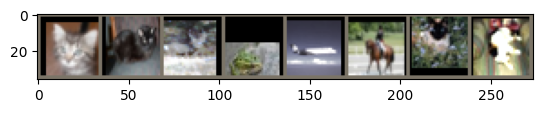

cat   cat   deer  frog  plane horse cat   cat  


In [ ]:
# Define data transforms for training set (with data augmentation)
# I am using AutoAugment which already applies more advanced trasformations
train_transform = transforms.Compose([     # chain multiple transform operations into a single pipeline
    transforms.RandomHorizontalFlip(p=0.5), # randomly flip image horizontally (50% probability)
    transforms.RandomCrop(INPUT_SIZE, padding=4),  # randomly crop image after padding. Fundamental because it forces the model to recognize an object even if it only sees a part of it
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10), # includes rotation, color shifting, contrast change, shearing
    transforms.ToTensor(), # convert the image to pytorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # normalize the tensor's values with CIFAR10 mean and standard dev
])


# define data transform for validation and test set (NO augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# create a dataset for training (with augmentations). Data augmentation is useful to  teach the model to be robust to variations
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
# create dataset for validation (WITHOUT augmentation) because validation set is used to get a fair and stable measurement of how well the model learned
valset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=test_transform)
#create test dataset (without augmentation)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)


# Split the data, using a generator  to ensure that the splits are identical
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
# A generator is an object that produces a sequence of pseudo-random numbers. It gives more control instead of relying on a single global random function
# the generator holds an internal state, and uses its current staate to generate a random number and then updates its staate
# I use it here to split the data into a training and validation set while applying different transformations to each
generator = torch.Generator().manual_seed(SEED) # for reproducibility
train_subset, _ = torch.utils.data.random_split(trainset, [train_size, val_size], generator=generator)
_, val_subset = torch.utils.data.random_split(valset, [train_size, val_size], generator=generator)

# Create the three loaders
# Prepare and serve batches of dataa to the model
trainloader = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valloader = torch.utils.data.DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



class_names = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


print(f"Training set size: {len(train_subset)}")
print(f"Validation set size: {len(val_subset)}")
print(f"Test set size: {len(testset)}")
print(f"Number of classes: {len(class_names)}")


def imshow(img):
    # Define the inverse normalization transformation
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Un-normalize
    img = img.numpy().transpose((1, 2, 0)) # Convert from pytorch tensor format (C, H, W) to matplotlib format (H, W, C)
    img = std * img + mean  #formula to reverse normalization
    img = np.clip(img, 0, 1) # Clip values to be between 0 and 1 as a safety step

    plt.imshow(img)
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images[:8]))
# Print labels
print(' '.join(f'{class_names[labels[j]]:5s}' for j in range(8)))


## 3️⃣ Design Complex CNN Architecture with Inception Bottlenecks

**Task**: Implement a sophisticated CNN architecture incorporating Inception-style bottleneck blocks.

**Requirements**:
- Create an Inception bottleneck module with multiple parallel paths
- Design the main CNN with multiple Inception blocks
- Use appropriate pooling, batch normalization, and dropout
- Implement skip connections where beneficial

In [ ]:
# TODO: Create InceptionBottleneck class inheriting from nn.Module
# TODO: In __init__(self, in_channels, out_1x1, reduce_3x3, out_3x3, reduce_5x5, out_5x5, out_pool):
#       Build four parallel paths:
#       Path 1: 1x1 convolution
#       - Conv2d(in_channels, out_1x1, 1) + BatchNorm2d + ReLU
#
#       Path 2: 1x1 reduction + 3x3 convolution
#       - Conv2d(in_channels, reduce_3x3, 1) + BatchNorm2d + ReLU
#       - Conv2d(reduce_3x3, out_3x3, 3, padding=1) + BatchNorm2d + ReLU
#
#       Path 3: 1x1 reduction + 5x5 convolution
#       - Conv2d(in_channels, reduce_5x5, 1) + BatchNorm2d + ReLU
#       - Conv2d(reduce_5x5, out_5x5, 5, padding=2) + BatchNorm2d + ReLU
#
#       Path 4: 3x3 max pooling + 1x1 projection
#       - MaxPool2d(3, stride=1, padding=1)
#       - Conv2d(in_channels, out_pool, 1) + BatchNorm2d + ReLU

# TODO: In forward(self, x):
#       - Pass input through all four paths
#       - Concatenate outputs along channel dimension
#       - Return concatenated result

# TODO: Create main CNN class inheriting from nn.Module
# TODO: In __init__(self, num_classes=10):
#       Initial layers:
#       - Conv2d(3, 64, 3, padding=1) + BatchNorm2d + ReLU
#       - Conv2d(64, 64, 3, padding=1) + BatchNorm2d + ReLU
#       - MaxPool2d(2, 2)
#       - Dropout2d(0.1)
#
#       Inception blocks:
#       - InceptionBottleneck(64, 16, 32, 64, 16, 32, 32)  # Output: 144 channels
#       - InceptionBottleneck(144, 32, 64, 128, 32, 64, 64) # Output: 288 channels
#       - MaxPool2d(2, 2)
#       - Dropout2d(0.2)
#
#       - InceptionBottleneck(288, 64, 128, 256, 64, 128, 128) # Output: 576 channels
#       - InceptionBottleneck(576, 128, 256, 512, 128, 256, 256) # Output: 1152 channels
#       - AdaptiveAvgPool2d((1, 1))
#
#       Classifier:
#       - Dropout(0.5)
#       - Linear(1152, num_classes)

# TODO: In forward(self, x):
#       - Pass through all layers sequentially
#       - Flatten before classifier
#       - Return logits

# TODO: Initialize model and move to device
# TODO: Print model architecture and parameter count
# TODO: Test with random input to verify output shape

In [ ]:
# Build a custon CNN inspired by Inception network [1]
# [1] C. Szegedy et al., "Going deeper with convolutions," 2015 IEEE Conference on Computer Vision and Pattern Recognition (CVPR), Boston, MA, USA, 2015, pp. 1-9, doi: 10.1109/CVPR.2015.7298594.

# Define the InceptionBottleneck class inheriting from nn.Module
# InceptionBottleneck's idea is to let the network decide for itself what kind of features are most important at each stage running 4 parallel paths and merging their outputs
# The 3x3 and 5x5 convolutions can be computationally expensive, so the bottleneck is the 1x1 convolution that comes before them

class InceptionBottleneck(nn.Module):
    def __init__(self, in_channels, out_1x1, reduce_3x3, out_3x3, reduce_5x5, out_5x5, out_pool):
        super().__init__()
        # Path 1: 1x1 convolution
        self.path1 = nn.Sequential(
            # DEFAULT: nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)
            nn.Conv2d(in_channels, out_1x1, kernel_size=1),
            # batch normalization described in  arXiv:1502.03167
            nn.BatchNorm2d(out_1x1),
            # I implemented GELU activation function instead of ReLU: ReLU is computationally cheap, fast and works well in most cases, but it can suffer from "dying ReLU problem" where neurons get stuck in a state where they only output 0 and stop learning
            # GELU is smoother around 0 and can help with gradient flow and make optimization more stable, but slightly more computationally expensive than ReLU
            # https://medium.com/better-ml/relu-vs-gelu-d322422f5147
            # https://www.mdpi.com/2078-2489/12/12/513
            nn.GELU('tanh')
        )
        # Path 2: 1x1 reduction + 3x3 convolution
        self.path2 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_3x3, kernel_size=1),
            nn.BatchNorm2d(reduce_3x3),
            nn.GELU('tanh'),
            nn.Conv2d(reduce_3x3, out_3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_3x3),
            nn.GELU('tanh')
        )
        # Path 3: 1x1 reduction + 5x5 convolution
        self.path3 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_5x5, kernel_size=1),
            nn.BatchNorm2d(reduce_5x5),
            nn.GELU('tanh'),
            nn.Conv2d(reduce_5x5, out_5x5, kernel_size=5, padding=2),
            nn.BatchNorm2d(out_5x5),
            nn.GELU('tanh')
        )

        # Path 4: 3x3 max pooling + 1x1 projection
        self.path4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_pool, kernel_size=1),
            nn.BatchNorm2d(out_pool),
            nn.GELU('tanh')
        )

# forward method for the inceptionbottleneck module, defining how input data flows through the module's layers to produce an output
    def forward(self, x):
        out1 = self.path1(x)
        out2 = self.path2(x)
        out3 = self.path3(x)
        out4 = self.path4(x)
        # concatenate a list of tensors. 1 specifies the dimension along wiìich to join them. 1 is the channel dimension
        # i am stacking the feature maps from all 4 paths together to create a single deeper output tensor that combines all the learned features
        return torch.cat([out1, out2, out3, out4], 1)

class ComplexCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(ComplexCNN, self).__init__()

        # Initial layers : take the raw input image with 3 color channels and perform initial convolution
        # to extract basic features like edges and simple textures
        self.pre_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU('tanh'),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU('tanh'),
            nn.MaxPool2d(kernel_size=2, stride=2), # to reduce dimensionality
            nn.Dropout2d(0.1) # randomly zero out entire 2D channels independently with 10% probability
        )

        # Inception blocks: stack 4 inceptionBottleneck modules, allowing the model to learn increasingly complex and abstract features from the data
        self.inception1 = InceptionBottleneck(64, 16, 32, 64, 16, 32, 32)  # Output: 16+64+32+32 = 144
        self.inception2 = InceptionBottleneck(144, 32, 64, 128, 32, 64, 64) # Output: 32+128+64+64 = 288

        # MaxPool and dropout between Inceptionbottleneck blocks to help prevent overfitting and control network complexity
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.2)

        self.inception3 = InceptionBottleneck(288, 64, 128, 256, 64, 128, 128) # Output: 64+256+128+128 = 576
        self.inception4 = InceptionBottleneck(576, 128, 256, 512, 128, 256, 256) # Output: 128+512+256+256 = 1152

        # Adaptive pooling and classifier
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1)) # shrink the multichannel feature map into a fixed-size vector
        self.dropout_final = nn.Dropout(0.5)
        self.fc = nn.Linear(1152, num_classes) # final decision-making layer

    #forward method to assemble the network
    def forward(self, x):
        x = self.pre_layers(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        x = self.inception3(x)
        x = self.inception4(x)
        x = self.avg_pool(x)
        x = torch.flatten(x, 1) # Flatten before classifier
        x = self.dropout_final(x)
        x = self.fc(x)
        return x

# model initialization
model = ComplexCNN(num_classes=NUM_CLASSES).to(device) # create an instance of the network

# model summary
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# sanity check: we pass a random tensor of the correct input shape to the model to confirm that all layers are connected properly
random_input = torch.randn(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE).to(device)
output = model(random_input)
print(f"Output shape: {output.shape}")

ComplexCNN(
  (pre_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='tanh')
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='tanh')
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (inception1): InceptionBottleneck(
    (path1): Sequential(
      (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='tanh')
    )
    (path2): Sequential(
      (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

## 4️⃣ Implement and Compare Different Optimizers

**Task**: Set up multiple optimizers and compare their performance.

**Requirements**:
- Implement SGD, Adam, and AdamW optimizers
- Use appropriate hyperparameters for each
- Create a function to easily switch between optimizers

In [ ]:
# TODO: Create function get_optimizer(model, optimizer_name, learning_rate):
#       Support the following optimizers:
#       - 'sgd': SGD with momentum=0.9, weight_decay=1e-4
#       - 'adam': Adam with betas=(0.9, 0.999), weight_decay=1e-4
#       - 'adamw': AdamW with betas=(0.9, 0.999), weight_decay=1e-2
#       Return the selected optimizer

# TODO: Initialize your chosen optimizer (recommend starting with 'adamw')
# TODO: Print optimizer configuration

In [ ]:
def get_optimizer(model, optimizer_name, learning_rate, **kwargs):
    """
    Returns an optimizer, allowing default hyperparameters to be overridden
    """
    # optimizer dictionary. Each key is a string name for an optimizer
    # each value is a tuple containing two items, the pytorch optimizer class, and a dictionary of default hyperparameters
    optimizer_map = {
        'sgd': (optim.SGD, {'momentum': 0.9, 'weight_decay': 1e-4}),
        'adam': (optim.Adam, {'betas': (0.9, 0.999), 'weight_decay': 1e-4}),
        'adamw': (optim.AdamW, {'betas': (0.9, 0.999), 'weight_decay': 1e-2})
    }

    optimizer_name = optimizer_name.lower()
    if optimizer_name not in optimizer_map:
        raise ValueError(f"Optimizer '{optimizer_name}' not supported.")

    optimizer_class, defaults = optimizer_map[optimizer_name]

    # possible to update defaults with any provided kwargs if needed
    defaults.update(kwargs)

    return optimizer_class(model.parameters(), lr=learning_rate, **defaults)

# Optuna will initialize the optimizer on each trial

## 5️⃣ Use Learning Rate Scheduling

**Task**: Implement learning rate scheduling for improved training dynamics.

**Requirements**:
- Use StepLR or CosineAnnealingLR scheduler
- Configure appropriate scheduling parameters
- Track learning rate changes during training

In [ ]:
# TODO: Create learning rate scheduler:
#       Option 1: StepLR(optimizer, step_size=15, gamma=0.1)
#       Option 2: CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
#       Choose one and justify your choice

# TODO: Create function to get current learning rate from optimizer
# TODO: Initialize lists to track learning rates during training

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


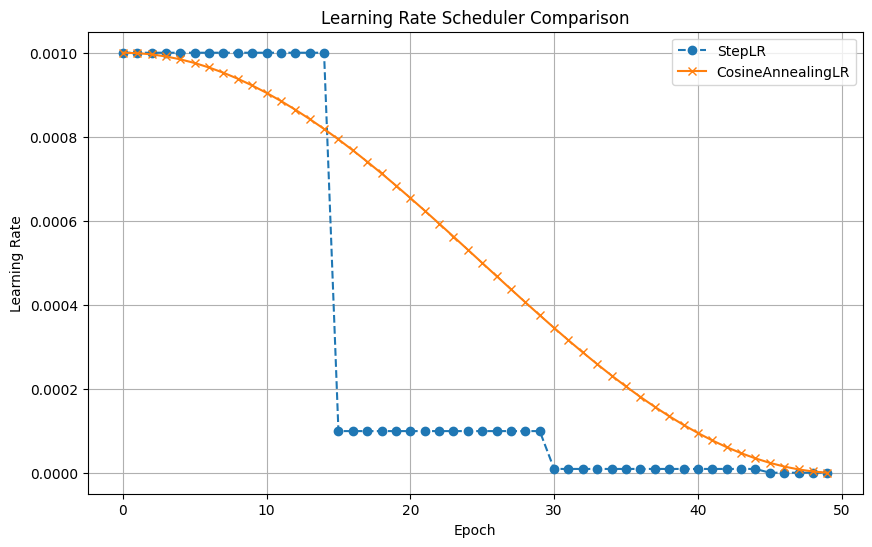

In [ ]:
# Learning rate scheduling is the technique of gradually changing the learning rate during training rather than keeping it fixed.
# The most common strategy is to start with a relatively high learning rate and decrease it over time.
# Let's simulate both requested learning rate schedulers

# create dummy model and optimizers
# The schedulers need an optimizer to be initialized
model = torch.nn.Linear(2, 1)
# We create two separate optimizers to ensure the simulations are independent.
optimizer_step = optim.SGD(model.parameters(), lr=LEARNING_RATE)
optimizer_cosine = optim.SGD(model.parameters(), lr=LEARNING_RATE)

# initialize schedulers
# StepLR decays the learning rate by a factor of 'gamma' every 'step_size' epochs
scheduler_step = optim.lr_scheduler.StepLR(optimizer_step, step_size=15, gamma=0.1)
# CosineAnnealingLR smoothly decays the learning rate following a cosine curve
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer_cosine, T_max=NUM_EPOCHS, eta_min=0)

# simulate training and record learning rates
lr_step_values = []
lr_cosine_values = []

for epoch in range(NUM_EPOCHS):
    # Record the current learning rate for StepLR
    lr_step_values.append(optimizer_step.param_groups[0]['lr'])
    # Record the current learning rate for CosineAnnealingLR
    lr_cosine_values.append(optimizer_cosine.param_groups[0]['lr'])

    # Step both schedulers to update the learning rate for the next epoch
    scheduler_step.step()
    scheduler_cosine.step()

# plot results
plt.figure(figsize=(10, 6))
plt.plot(range(NUM_EPOCHS), lr_step_values, label='StepLR', marker='o', linestyle='--')
plt.plot(range(NUM_EPOCHS), lr_cosine_values, label='CosineAnnealingLR', marker='x', linestyle='-')
plt.title('Learning Rate Scheduler Comparison')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True)
plt.show()

# seeing the results, I chhoose CosineAnnealingLR which smoothly decayse the rate, providing a more stable and effective optimization path compared to StepLR which is more abrupt

## 6️⃣ Apply Regularization Techniques  

**Task**: Implement various regularization methods to prevent overfitting.

**Requirements**:
- Use dropout in your model (already included in architecture)
- Implement early stopping mechanism
- Add L2 weight decay (already in optimizer)
- Optional: implement label smoothing

In [ ]:
# TODO: Create EarlyStopping class:
#       - __init__(self, patience=7, min_delta=0, restore_best_weights=True)
#       - __call__(self, val_loss, model) method that:
#         * Checks if validation loss improved by min_delta
#         * Increments counter if no improvement
#         * Saves best model weights if improvement
#         * Returns True if should stop (patience exceeded)

# TODO: Initialize early stopping with patience=10

# TODO: Optional: Create label smoothing loss function
#       - LabelSmoothingCrossEntropy class with smoothing parameter
#       - Mixes one-hot labels with uniform distribution

In [ ]:
# EarlyStopping monitors the model's performance on the validation set and stops the training process automatically if performance stops improving
#this saves time and prevents overfitting
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, restore_best_weights=True):
        # the number of epochs to wait for improvement before improving
        self.patience = patience
        # minimum change in the monitored metric to be considered an improvement
        self.min_delta = min_delta
        # whether to restore model weights from the epoch with the best value of monitored metric
        self.restore_best_weights = restore_best_weights
        # to store the state of the best model so far
        self.best_model = None
        # stores best validation loss seen, initialized to infinity
        self.best_loss = float('inf')
        # counts the number of consecutive epochs with no improvement
        self.counter = 0
        # status message
        self.status = ""

    def __call__(self, val_loss, model):
        # Checks if validation loss improved
        if val_loss < self.best_loss - self.min_delta:
          # if so, update best loss
            self.best_loss = val_loss
            # ...and reset the patience counter
            self.counter = 0
            # save copy of current model's weights
            if self.restore_best_weights:
                self.best_model = copy.deepcopy(model.state_dict())
            self.status = f"Improvement found, counter reset to {self.counter}."
        else:
          # if no improvement, increment patience counter
            self.counter += 1
            self.status = f"No improvement, counter is {self.counter}."

        # check if patence has been exceeded
        if self.counter >= self.patience:
            self.status = f"Early stopping triggered after {self.counter} epochs."
            # if enabled, load the best model weights into the model
            if self.restore_best_weights:
                model.load_state_dict(self.best_model)
            # Return True to signal that training should stop
            return True
        # return False to continue training
        return False


early_stopper = EarlyStopping(patience=10, min_delta=0.001)

# custom loss function that implements label smoothing as a regularization technique
# helps the model generalize better
# instead of using hard labels (0, 1, ...), label smoothing creates soft labels, assigning 0.9 to tje correct class and distributing the remaining amount among the incorrect classes
# this discourages the model from making overconfident predictions, improving accuraacy on unseen data
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, classes, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing
        self.cls = classes
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, pred, target):
        pred = self.log_softmax(pred)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), 1.0 - self.smoothing)
        return torch.mean(torch.sum(-true_dist * pred, dim=1))

print("EarlyStopping and LabelSmoothingCrossEntropy (optional) are defined.")

EarlyStopping and LabelSmoothingCrossEntropy (optional) are defined.


## 7️⃣ Training Loop with Advanced Features

**Task**: Implement comprehensive training loop with all optimizations.

**Requirements**:
- Track multiple metrics during training
- Implement proper validation
- Save best model checkpoints
- Monitor learning rate and loss curves

In [ ]:
# TODO: Define loss function (CrossEntropyLoss or LabelSmoothingCrossEntropy)

# TODO: Initialize tracking lists for:
#       - train_losses, val_losses
#       - train_accuracies, val_accuracies
#       - learning_rates

# TODO: Create training loop for NUM_EPOCHS:
#
#       Training phase:
#       - Set model to train mode
#       - For each batch in trainloader:
#         * Move data to device
#         * Zero gradients
#         * Forward pass
#         * Calculate loss
#         * Backward pass and optimize
#         * Track running loss and accuracy
#
#       Validation phase:
#       - Set model to eval mode
#       - With torch.no_grad():
#         * Calculate validation loss and accuracy
#         * Track metrics
#
#       Scheduling and monitoring:
#       - Step learning rate scheduler
#       - Check early stopping
#       - Print epoch statistics
#       - Save best model if validation improved

# TODO: Plot training curves (loss and accuracy)
# TODO: Plot learning rate schedule

In [ ]:
# Here we perform automated hyperparameter optimization using Optuna library
# it runs many different training experiments to find the best combination of hyperparameters for the model
#
# OBJECTIVE FUNCTION
#The objective function defines a complete, self-contained training and validation run for one set of hyperparameters
def objective(trial):
    """
    This function defines a single training run. Optuna calls this function
    with a 'trial' object that suggests different hyperparameter values.
    """
    # Suggest hyperparameters for this trial
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["adamw", "sgd"])
    dropout_rate = trial.suggest_float("dropout", 0.2, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)

    # Setup Model and Optimizer for this trial
    model = ComplexCNN(num_classes=NUM_CLASSES).to(device)
    model.dropout_final = nn.Dropout(dropout_rate) # Apply the suggested dropout rate

    # Use flexible function to get the optimizer with the suggested values
    optimizer = get_optimizer(model, optimizer_name, lr, weight_decay=weight_decay)

    # Use few epochs per trial to make the search faster
    trial_epochs = 10
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=trial_epochs)
    criterion = LabelSmoothingCrossEntropy(classes=NUM_CLASSES, smoothing=0.1)

    # training and validation loop for this trial
    best_val_acc = 0.0
    for epoch in range(trial_epochs):
        model.train()
        for inputs, labels in trainloader: # Assumes trainloader is defined globally
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in valloader: # Assumes valloader is defined globally
                inputs, labels = inputs.to(device), labels.to(device)
                _, predicted = torch.max(model(inputs).data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_acc = correct_val / total_val

        # Keep track of the best accuracy achieved during this trial
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc

        # Pruning: Report intermediate results to stop unpromising trials early
        trial.report(epoch_val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        scheduler.step()

    # return final score for trial
    return best_val_acc


# Create an Optuna study. 'direction="maximize"' means we want to maximize the validation accuracy.
# the study is the manager that controls the entire optimization process
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())

# Start the optimization
study.optimize(objective, n_trials=15)

# --- Print the Best Results ---
print("\n--- Hyperparameter Optimization Finished ---")
print(f"Best trial validation accuracy: {study.best_trial.value}")
print("Best hyperparameters found:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-07-24 09:33:45,889] A new study created in memory with name: no-name-1e9dd8c1-fa6d-4e6b-94be-db967632dde8
[I 2025-07-24 09:36:40,799] Trial 0 finished with value: 0.8692 and parameters: {'learning_rate': 0.0010093421678835657, 'optimizer': 'adamw', 'dropout': 0.4014817102761451, 'weight_decay': 0.0011208517758415177}. Best is trial 0 with value: 0.8692.
[I 2025-07-24 09:39:34,911] Trial 1 finished with value: 0.5705 and parameters: {'learning_rate': 0.0012227338560790767, 'optimizer': 'sgd', 'dropout': 0.37808936617112143, 'weight_decay': 0.001438544580352934}. Best is trial 0 with value: 0.8692.
[I 2025-07-24 09:42:27,828] Trial 2 finished with value: 0.839 and parameters: {'learning_rate': 0.0003821366097896119, 'optimizer': 'adamw', 'dropout': 0.4806550926921181, 'weight_decay': 0.004914708607501192}. Best is trial 0 with value: 0.8692.
[I 2025-07-24 09:45:20,629] Trial 3 finished with value: 0.8719 and parameters: {'learning_rate': 0.0033319816080493296, 'optimizer': 'adamw


--- Hyperparameter Optimization Finished ---
Best trial validation accuracy: 0.8719
Best hyperparameters found:
    learning_rate: 0.0033319816080493296
    optimizer: adamw
    dropout: 0.42379224474210175
    weight_decay: 0.0047480801985216314


In [ ]:
# Manually update hyperparameters from Optuna's result
LEARNING_RATE = 0.0033

optimizer_name = 'adamw'

best_weight_decay = 0.00676


In [ ]:
# --- RE-INITIALIZE THE CORRECT MODEL  ---
# This ensures we are training the ComplexCNN, not the dummy model from the scheduler visualization.
model = ComplexCNN(num_classes=NUM_CLASSES).to(device)

# Using Label Smoothing loss function for potentially better generalization
criterion = LabelSmoothingCrossEntropy(classes=NUM_CLASSES, smoothing=0.1)

# Initialize tracking lists to setup a dictionary to record the loss and accuracy for plotting later
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_model_wts = None

# Initialize optimizer and scheduler using the best parameters
optimizer = get_optimizer(model, optimizer_name, LEARNING_RATE, weight_decay=best_weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Initialize early stopping to monitor overfitting
early_stopper = EarlyStopping(patience=10, min_delta=0.001)

# Function to get current learning rate
def get_current_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

# Create training loop for NUM_EPOCHS
print("Starting Training...")
for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # clears old gradients
        outputs = model(inputs) # makes a forward pass
        loss = criterion(outputs, labels) #calculates the error
        loss.backward() # backpropagation
        optimizer.step() # updates the model weights

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Update progress bar
        train_pbar.set_postfix({'loss': loss.item(), 'acc': (predicted == labels).sum().item() / labels.size(0)})

    # Validation phase
    model.eval() # puts the model in "evaluation mode," disabling features like dropout
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    #
    val_pbar = tqdm(valloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
    with torch.no_grad(): # temporarily disables gradient calculations, which saves memory and speeds up the process
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            val_pbar.set_postfix({'loss': criterion(outputs, labels).item(), 'acc': (predicted == labels).sum().item() / labels.size(0)})

    # Scheduling and monitoring
    epoch_train_loss = running_loss / len(train_subset)
    epoch_train_acc = correct_train / total_train
    # Divide by validation set size
    epoch_val_loss = running_val_loss / len(val_subset)
    epoch_val_acc = correct_val / total_val

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    history['lr'].append(get_current_lr(optimizer))

    scheduler.step()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} -> "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f} | "
          f"LR: {get_current_lr(optimizer):.6f}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_model_cifar10.pth')
        print(f"✨ New best model saved with Val Acc: {best_val_acc:.4f}")

    if early_stopper(epoch_val_loss, model):
        print(early_stopper.status)
        break

print("Finished Training.")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

if best_model_wts is not None:
  model.load_state_dict(best_model_wts)
else:
  print("No best model weights saved. Using the final epoch weights.")

Starting Training...


Epoch 1/50 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/50 -> Train Loss: 1.9365, Train Acc: 0.3295 | Val Loss: 1.5057, Val Acc: 0.5624 | LR: 0.003017
✨ New best model saved with Val Acc: 0.5624


Epoch 2/50 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 49/50 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 49/50 -> Train Loss: 0.7660, Train Acc: 0.9157 | Val Loss: 0.6328, Val Acc: 0.9761 | LR: 0.000003
✨ New best model saved with Val Acc: 0.9761


Epoch 50/50 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 50/50 -> Train Loss: 0.7651, Train Acc: 0.9154 | Val Loss: 0.6332, Val Acc: 0.9761 | LR: 0.000000
Finished Training.
Best Validation Accuracy: 0.9761


## 8️⃣ Evaluate Model with Advanced Metrics

**Task**: Comprehensive evaluation using multiple metrics and visualizations.

**Requirements**:
- Calculate accuracy, precision, recall, F1-score
- Generate confusion matrix
- Analyze per-class performance
- Visualize misclassified examples

In [ ]:
# TODO: Load best model weights

# TODO: Create evaluation function that calculates:
#       - Overall accuracy
#       - Per-class accuracy
#       - Precision, recall, F1-score (macro and weighted averages)
#       - Confusion matrix

# TODO: Generate predictions on test set:
#       - Set model to eval mode
#       - Collect all predictions and true labels
#       - Calculate all metrics using sklearn.metrics

# TODO: Create confusion matrix visualization:
#       - Use seaborn heatmap or matplotlib imshow
#       - Add class names as labels
#       - Display percentages and counts

# TODO: Display classification report with per-class metrics

# TODO: Find and visualize misclassified examples:
#       - Identify worst performing classes
#       - Show examples of incorrect predictions
#       - Display true label vs predicted label


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

       plane       0.93      0.93      0.93      1000
         car       0.96      0.97      0.97      1000
        bird       0.89      0.89      0.89      1000
         cat       0.84      0.81      0.83      1000
        deer       0.90      0.94      0.92      1000
         dog       0.87      0.86      0.87      1000
        frog       0.94      0.94      0.94      1000
       horse       0.95      0.95      0.95      1000
        ship       0.94      0.96      0.95      1000
       truck       0.96      0.95      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



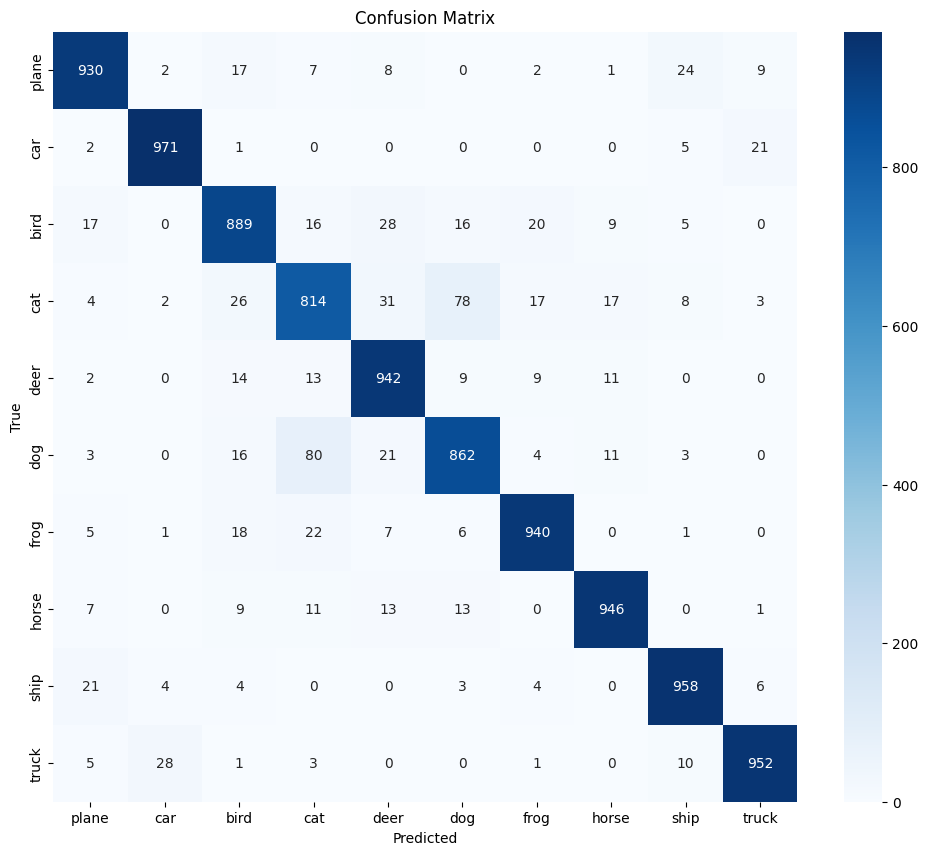


Visualizing some misclassified examples:


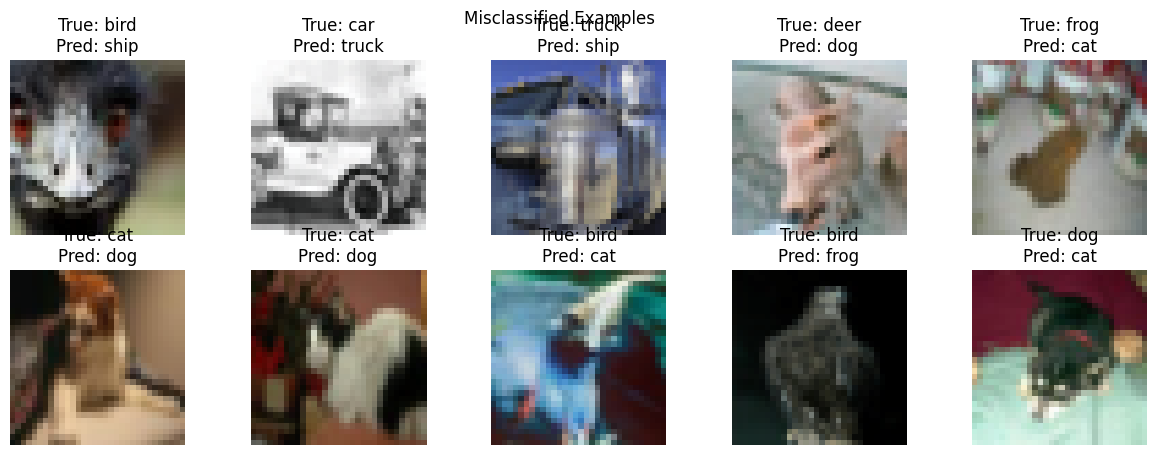

In [ ]:
# This block performs evaluation of the trained model on test set
# Load the weights of the best model saved during training
model.load_state_dict(torch.load('best_model_cifar10.pth'))
# Move the model to the selected device (GPU or CPU)
model.to(device)
# Set the model to evaluation mode
model.eval()


def evaluate_model(model, dataloader, device, class_names):
    """
    Evaluates the model on a given dataset, prints a classification report,
    and displays a confusion matrix
    """
    # Initialize empty lists to store all predictions and true labels
    y_pred = []
    y_true = []

    # Disable gradient calculations to save memory and speed up inference
    with torch.no_grad():
        # Loop over the dataloader with a progress bar
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            # Move data to the selected device
            inputs, labels = inputs.to(device), labels.to(device)
            # Get the model's raw output (logits)
            outputs = model(inputs)
            # Get the predicted class by finding the index with the highest score.
            _, predicted = torch.max(outputs, 1)
            # Store the predictions and true labels after moving them back to the CPU.
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Generate and print a detailed classification report (precision, recall, f1-score).
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Generate and visualize a confusion matrix to see which classes are being confused.
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    # Use seaborn for a visually appealing heatmap.
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # Return the collected labels and predictions for further analysis if needed.
    return y_true, y_pred

# Call the function to evaluate the model on the test set.
y_true, y_pred = evaluate_model(model, testloader, device, class_names)


def visualize_misclassified(model, dataloader, device, class_names, num_images=10):
    """
    Finds and displays a sample of misclassified images from a dataset.
    """
    # Initialize lists to store the images and labels of misclassified examples.
    misclassified_images = []
    misclassified_labels = []
    correct_labels = []

    # Set model to evaluation mode and disable gradients.
    model.eval()
    with torch.no_grad():
        # Loop through the dataloader until we have enough examples.
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            # Create a boolean mask to identify which predictions are incorrect.
            misclassified_mask = (predicted != labels)

            # Iterate through the batch and collect the misclassified examples.
            for i in range(len(misclassified_mask)):
                if misclassified_mask[i]:
                    misclassified_images.append(images[i].cpu())
                    misclassified_labels.append(predicted[i].cpu().item())
                    correct_labels.append(labels[i].cpu().item())
            # Stop once we have collected the desired number of images.
            if len(misclassified_images) >= num_images:
                break

    # --- Plotting the Misclassified Examples ---
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(2, 5, i + 1)

        # Proper un-normalization for visualization
        img_tensor = misclassified_images[i]
        # Define the same mean and std used for normalization
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        # Convert from PyTorch format (C, H, W) to Matplotlib format (H, W, C)
        npimg = img_tensor.numpy().transpose((1, 2, 0))
        # Reverse the normalization process.
        npimg = std * npimg + mean
        # Clip values to the valid [0, 1] range for display
        npimg = np.clip(npimg, 0, 1)

        plt.imshow(npimg)
        # Set the title to show the true vs. the incorrectly predicted label
        plt.title(f"True: {class_names[correct_labels[i]]}\nPred: {class_names[misclassified_labels[i]]}")
        plt.axis('off')

    plt.suptitle("Misclassified Examples")
    plt.show()

# Call the function to visualize misclassified examples from the test setS
print("\nVisualizing some misclassified examples:")
visualize_misclassified(model, testloader, device, class_names, num_images=10)

The confusion matrix shows that the model is very good at recognizing the different classes. The biggest confusion happens between visually similar classes such as cats/dogs and plane/ship.

## 9️⃣ Visualize Results

**Task**: Create comprehensive visualizations of model performance and behavior.

**Requirements**:
- Plot training/validation curves
- Visualize model predictions
- Show sample activations or feature maps
- Create performance comparison charts

In [ ]:
# TODO: Create comprehensive plotting function that shows:
#       1. Training and validation loss curves
#       2. Training and validation accuracy curves
#       3. Learning rate schedule
#       4. Confusion matrix heatmap

# TODO: Create prediction visualization function:
#       - Show grid of test images with predicted vs true labels
#       - Highlight correct (green) and incorrect (red) predictions
#       - Display confidence scores

# TODO: Optional: Visualize feature maps from convolutional layers:
#       - Hook into intermediate layers
#       - Show activation patterns for sample images
#       - Compare activations across different classes

# TODO: Optional: Create architecture diagram or summary visualization

# TODO: Display all visualizations with proper titles and labels

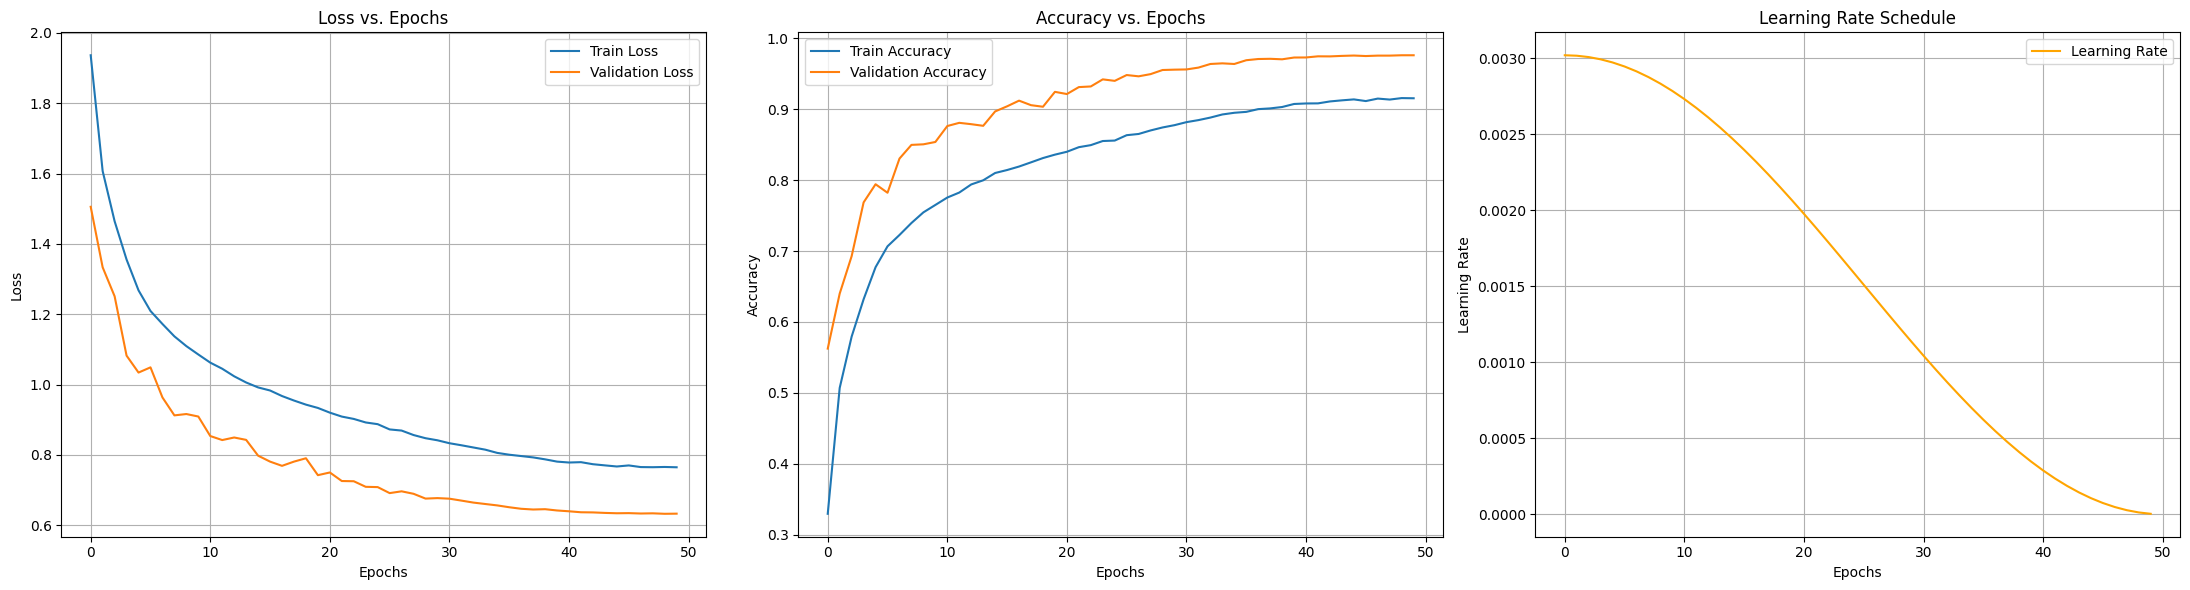


Visualizing some sample predictions:


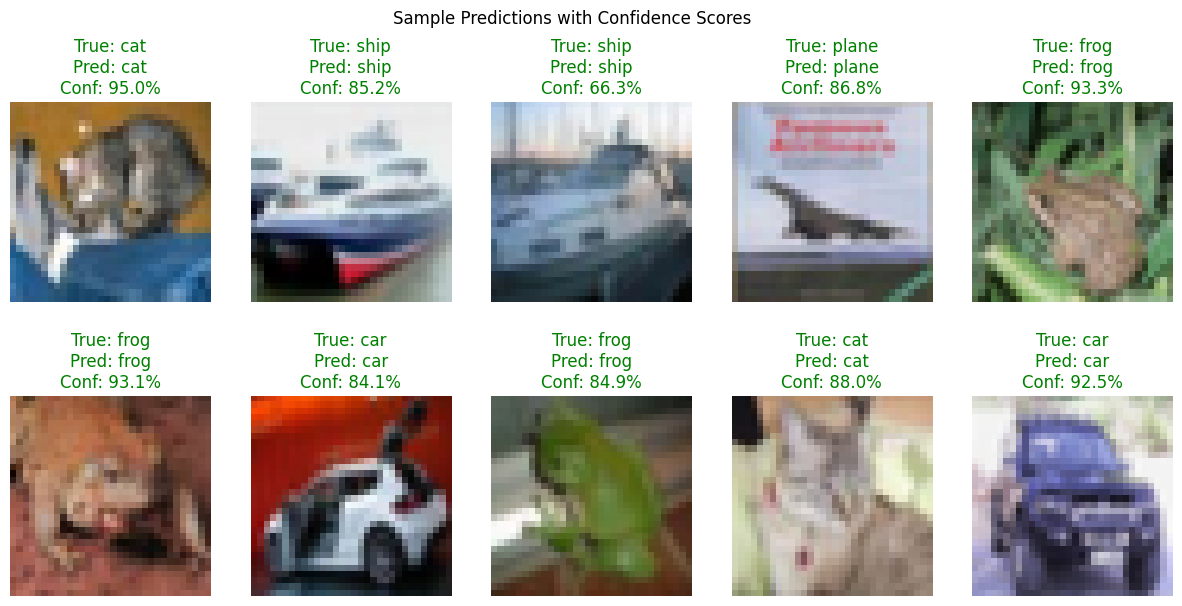

In [ ]:

def plot_training_history(history):
    fig, axs = plt.subplots(1, 3, figsize=(22, 6))

    # 1. Plot Training & Validation Loss
    axs[0].plot(history['train_loss'], label='Train Loss')
    axs[0].plot(history['val_loss'], label='Validation Loss')
    axs[0].set_title('Loss vs. Epochs')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # 2. Plot Training & Validation Accuracy
    axs[1].plot(history['train_acc'], label='Train Accuracy')
    axs[1].plot(history['val_acc'], label='Validation Accuracy')
    axs[1].set_title('Accuracy vs. Epochs')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)

    # 3. Plot Learning Rate Schedule
    axs[2].plot(history['lr'], label='Learning Rate', color='orange')
    axs[2].set_title('Learning Rate Schedule')
    axs[2].set_xlabel('Epochs')
    axs[2].set_ylabel('Learning Rate')
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

def visualize_predictions(model, dataloader, device, class_names, num_images=10):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images[:num_images].to(device), labels[:num_images].to(device)

    with torch.no_grad():
        outputs = model(images)

        #  Get confidence scores using softmax
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidences, predicted = torch.max(probabilities, 1)

    images = images.cpu()

    plt.figure(figsize=(15, 7))
    for i in range(num_images):
        plt.subplot(2, 5, i+1)

        # un-normalization
        img_tensor = images[i]
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        npimg = img_tensor.numpy().transpose((1, 2, 0))
        npimg = std * npimg + mean
        npimg = np.clip(npimg, 0, 1)

        plt.imshow(npimg)

        is_correct = (predicted[i] == labels[i])
        color = 'green' if is_correct else 'red'

        # Add confidence score to the title
        pred_label = class_names[predicted[i]]
        true_label = class_names[labels[i]]
        confidence_score = confidences[i].item() * 100

        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence_score:.1f}%", color=color)
        plt.axis('off')

    plt.suptitle("Sample Predictions with Confidence Scores")
    plt.show()

print("\nVisualizing some sample predictions:")
visualize_predictions(model, testloader, device, class_names, num_images=10)

Train and validation losses steadily decrease. The validation loss is consistently below the training loss, so there is no sign of overfitting.

Train and validation accuracy increase steadily. Validation accuracy increases faster and reaches a final value faster than trining accuracy. This is a strong indicator that the model generalizes well.

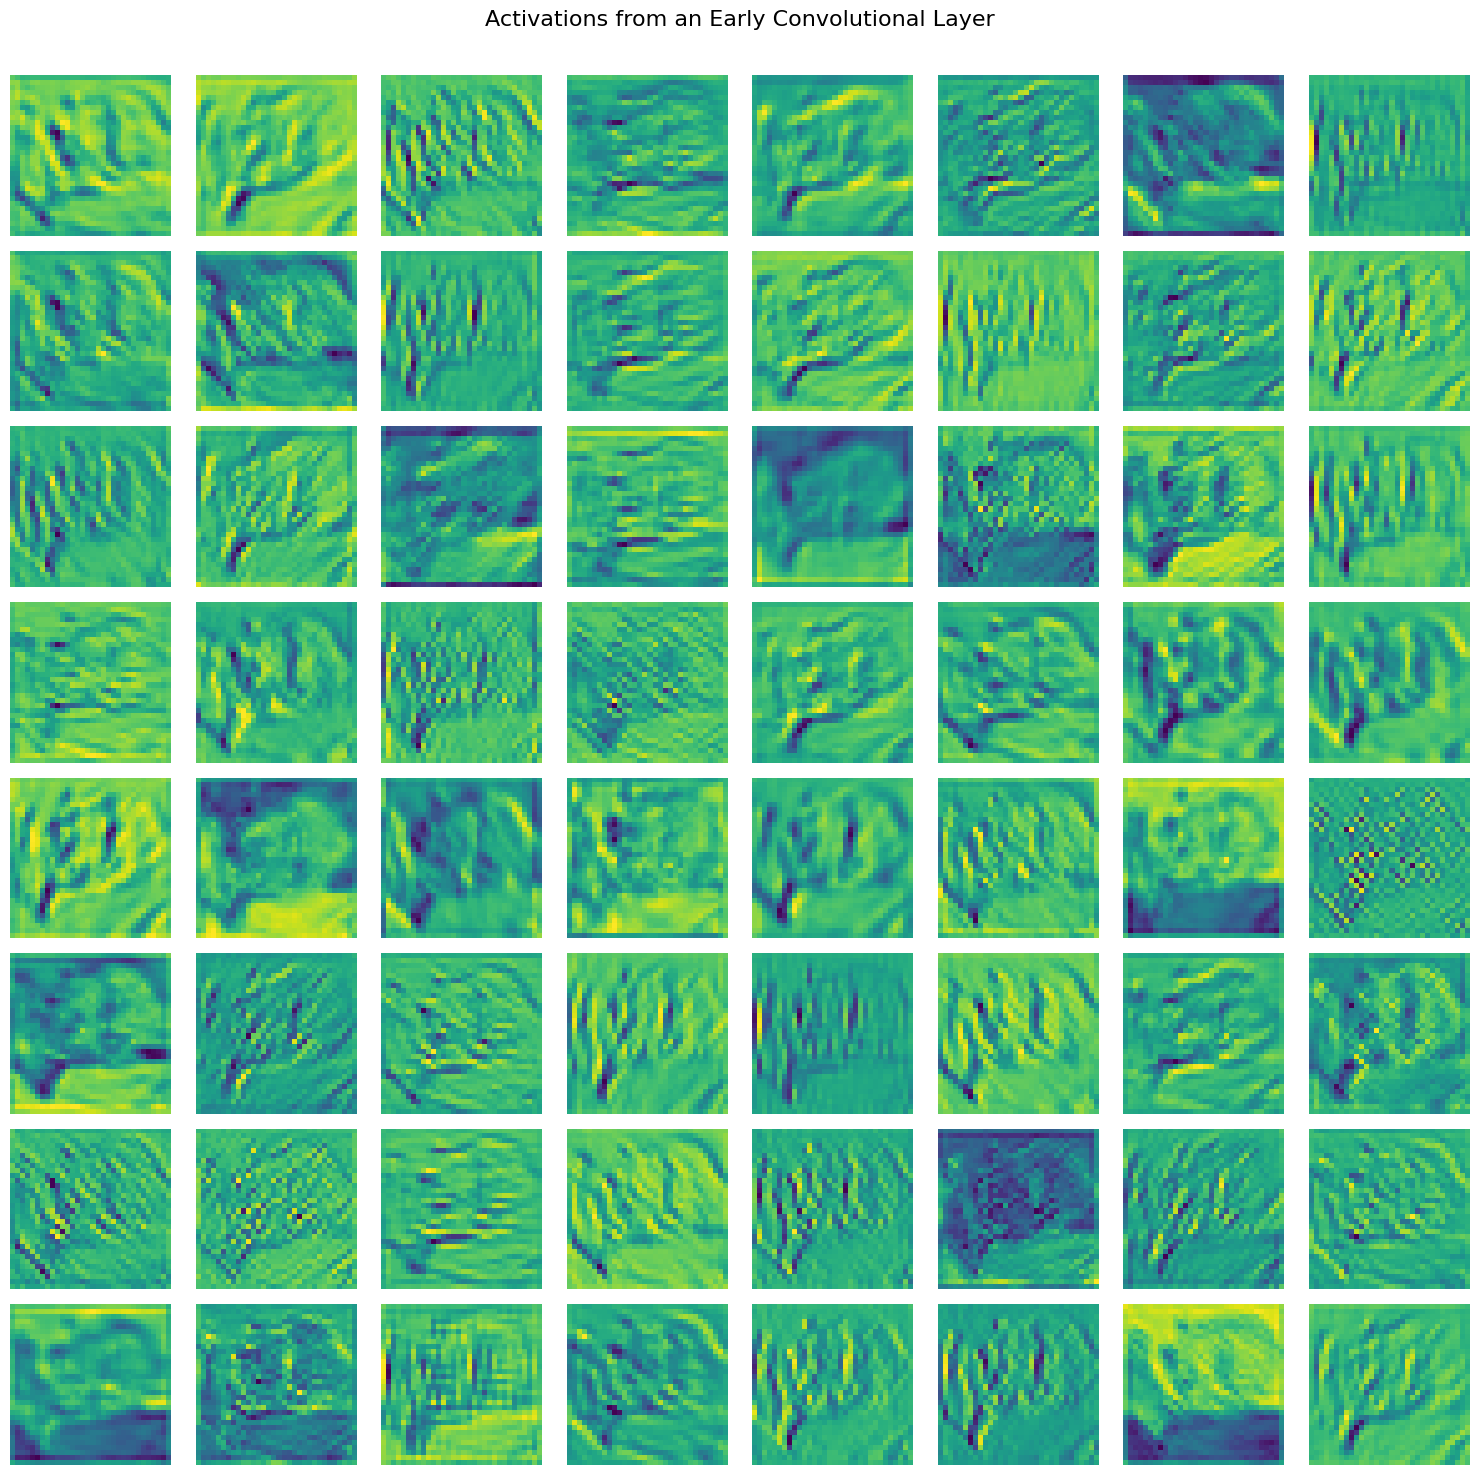

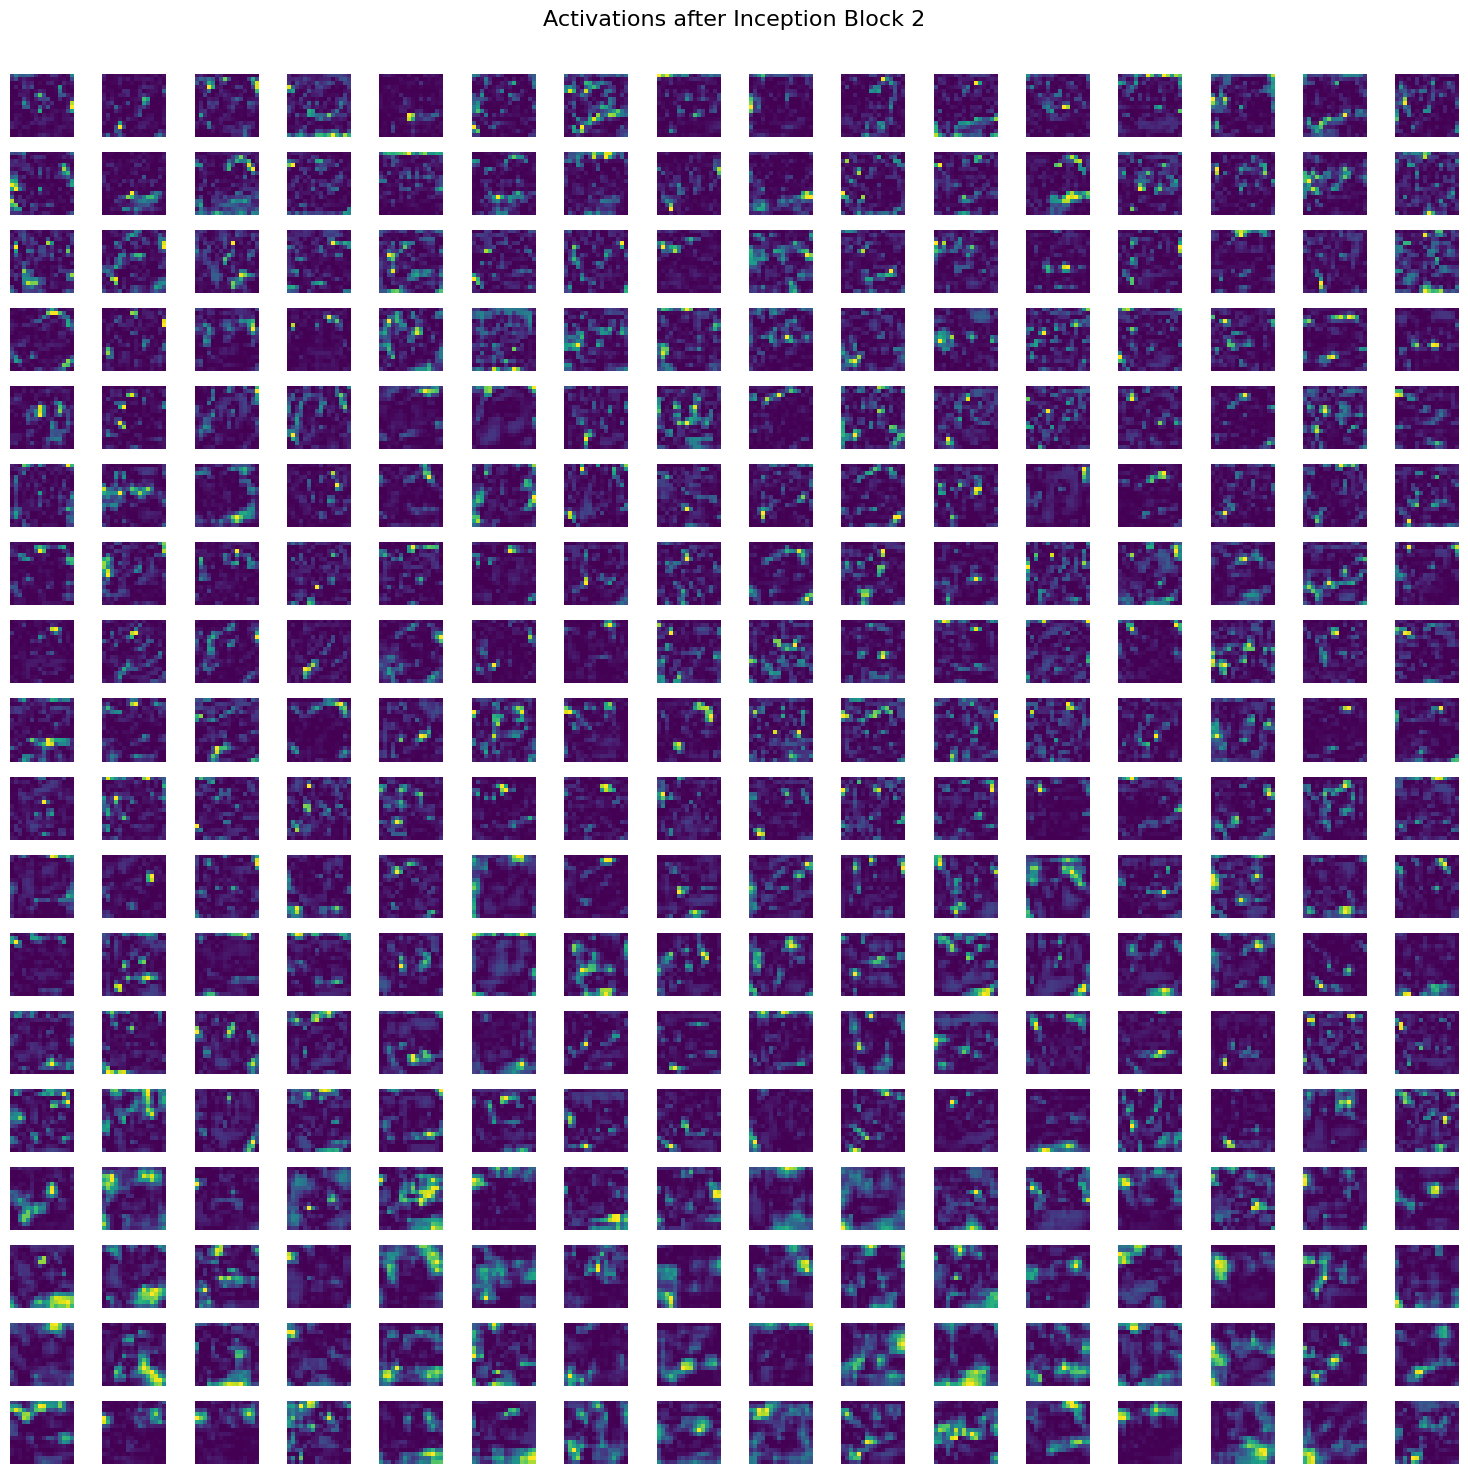

In [ ]:
# Function to visualize feature maps
def visualize_feature_maps(activation, title):
    """Plots the feature maps from a given activation tensor."""
    num_features = activation.shape[1] # Get the number of channels/feature maps

    # Determine the grid size for plotting
    cols = int(num_features**0.5)
    rows = (num_features // cols) + (1 if num_features % cols > 0 else 0)

    fig = plt.figure(figsize=(15, 15))
    plt.suptitle(title, fontsize=16)

    for i in range(num_features):
        ax = fig.add_subplot(rows, cols, i+1)
        # Squeeze to remove batch and channel dimensions for plotting
        feature_map = activation[0, i, :, :].detach().cpu().numpy()
        ax.imshow(feature_map, cmap='viridis')
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# --- Hook Setup to Capture Activations ---
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Get a single image from the test set
images, labels = next(iter(testloader))
sample_image = images[0].unsqueeze(0).to(device) # Add batch dimension

# Register hooks on the layers you want to inspect
handle1 = model.pre_layers[3].register_forward_hook(get_activation('Early Conv Layer'))
handle2 = model.inception2.register_forward_hook(get_activation('Inception Block 2'))

# Perform a forward pass to trigger the hooks
model.eval()
with torch.no_grad():
    output = model(sample_image)

# Remove the hooks after use to avoid clutter
handle1.remove()
handle2.remove()

# Visualize the captured feature maps
visualize_feature_maps(activations['Early Conv Layer'], 'Activations from an Early Convolutional Layer')
visualize_feature_maps(activations['Inception Block 2'], 'Activations after Inception Block 2')

These images show the model's feature maps. Early layers show very simple patterns, with adges at different angles, simpler color gradients, and basic textures.  The second image shows activation maps after inceptioBlock 2, which is deeper in the network. It combines the simple edge and color signals to recognie more meaaningful concepts like fur texture, a wheel shape, etc.

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipython-input-72-2899947364.py:76: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  heatmap_color = Image.fromarray(heatmap_color_np.astype('uint8'), 'RGB')


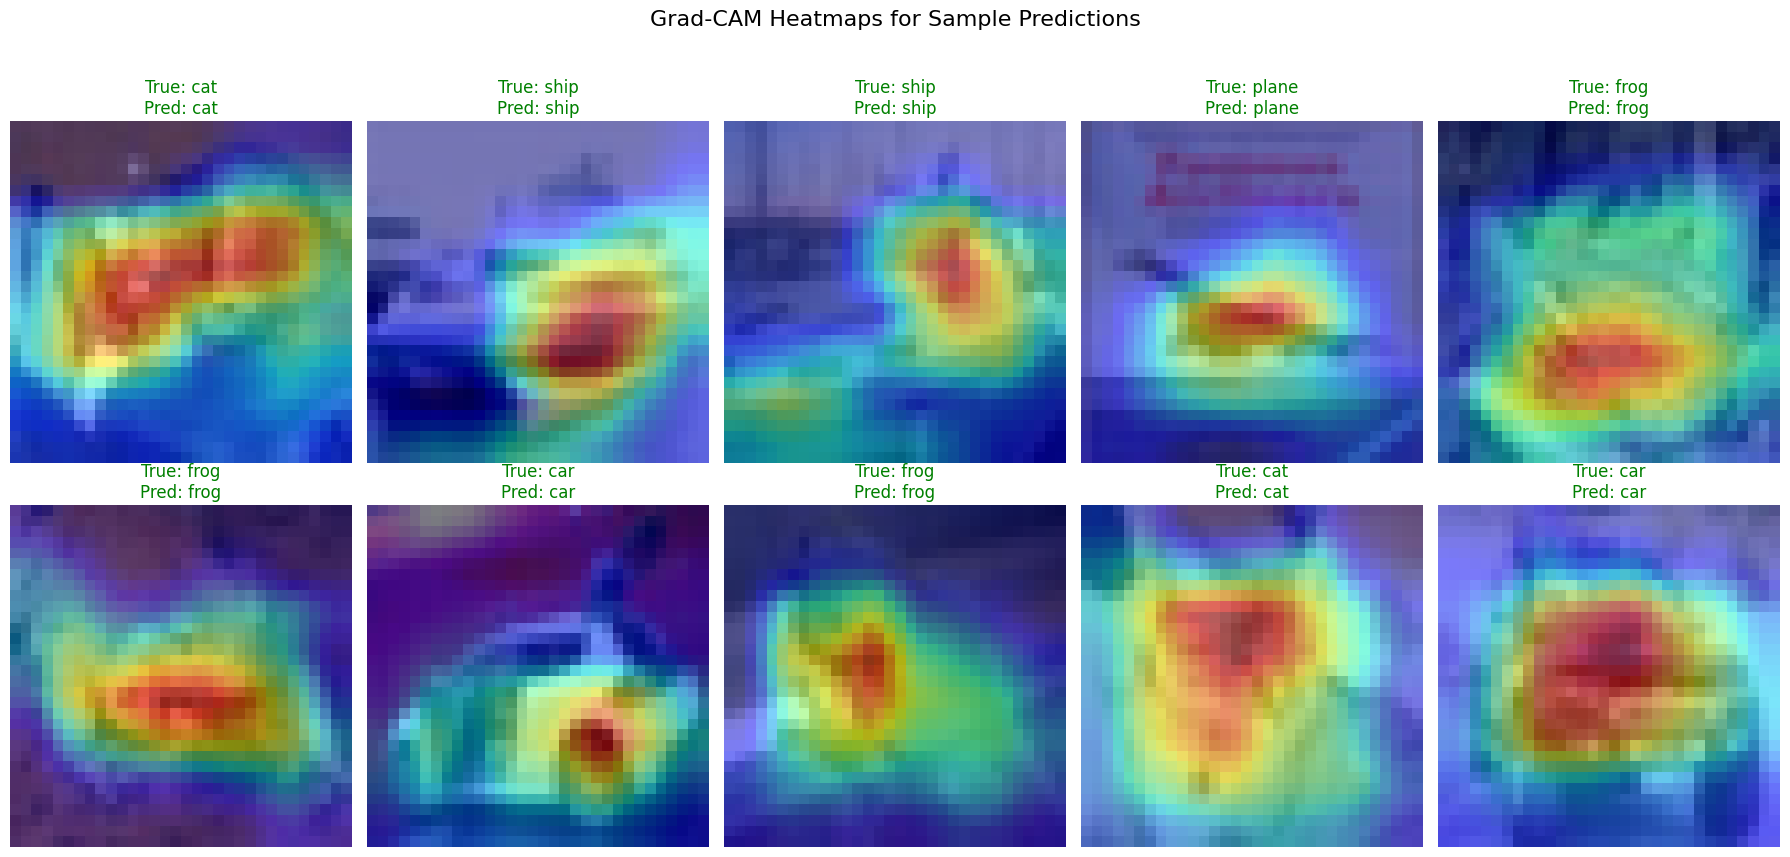

In [ ]:
# GradCam creates and displays a heatmap that shows which parts of an image the model focused on to make a specific prediction.

# GradCam class
class GradCam:
    """
    Helper class to generate Grad-CAM heatmaps.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        # A "hook" is a function that runs during the forward or backward pass.
        # We register hooks on the target layer to "spy" on its data.
        self.forward_hook_handle = target_layer.register_forward_hook(self.forward_hook)
        self.backward_hook_handle = target_layer.register_backward_hook(self.backward_hook)

    # This hook captures the output (activations) of the target layer during the forward pass
    def forward_hook(self, module, input, output):
        self.activations = output

    # This hook captures the gradients flowing backward through the target layer
    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.eval()
        # forward pass to get model output
        output = self.model(input_tensor)
        if class_idx is None:
          # if no class is specified, use the class with highest score
            class_idx = output.argmax(dim=1).item()

        #backward pass to get gradients
        self.model.zero_grad()
        target_one_hot = torch.zeros_like(output)
        target_one_hot[0][class_idx] = 1 # We only care about the gradient for our target class.
        # Propagate the gradient for the target class back through the network
        target_one_hot = target_one_hot.to(output.device)
        output.backward(gradient=target_one_hot, retain_graph=True)

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Grad-CAM hooks did not capture gradients or activations.")

        # calculate the heatmap
        # Pool the gradients to get the importance weight for each channel
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations.to(pooled_gradients.device)

        # Weight the activation maps with the pooled gradients
        for i in range(activations.shape[1]):
            activations[0, i, :, :] *= pooled_gradients[i]

        # Average the weighted activation maps and apply ReLU
        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        max_val = torch.max(heatmap)
        if max_val > 1e-8:
            heatmap /= max_val
        else:
            heatmap = torch.zeros_like(heatmap)

        return heatmap.detach().cpu().numpy()

    def remove_hooks(self):
        self.forward_hook_handle.remove()
        self.backward_hook_handle.remove()

def create_superimposed_image(img_tensor, heatmap):
    """Helper function to create a single superimposed PIL image."""
    # Un-normalize the image tensor
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    pil_img = to_pil_image(img)

    # Resize heatmap and apply colormap
    heatmap_img = Image.fromarray((heatmap * 255).astype('uint8'))
    heatmap_resized = heatmap_img.resize(pil_img.size, Image.Resampling.BILINEAR)
    heatmap_np = np.array(heatmap_resized)
    heatmap_color_np = plt.get_cmap('jet')(heatmap_np)[:, :, :3] * 255
    heatmap_color = Image.fromarray(heatmap_color_np.astype('uint8'), 'RGB')

    # Blend the original image and the heatmap
    return Image.blend(pil_img, heatmap_color, alpha=0.5)


def plot_grad_cam_grid(model, dataloader, device, class_names, num_images=10):
    """Generates and displays a grid of Grad-CAM visualizations."""
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images[:num_images].to(device), labels[:num_images].to(device)

    # Initialize Grad-CAM with the model and the target layer
    try:
        target_layer = model.inception4.path2[3] # Last 3x3 conv layer
        grad_cam = GradCam(model, target_layer=target_layer)
    except Exception as e:
        print(f"Error selecting target layer: {e}")
        return

    plt.figure(figsize=(18, 9))
    for i in range(num_images):
        ax = plt.subplot(2, 5, i + 1)

        img_tensor_batch = images[i].unsqueeze(0)

        # Get the model's prediction
        with torch.no_grad():
            output = model(img_tensor_batch)
            pred_label_idx = output.argmax(dim=1).item()

        # Generate heatmap and the superimposed image
        heatmap = grad_cam.generate_heatmap(img_tensor_batch, class_idx=pred_label_idx)
        superimposed_img = create_superimposed_image(images[i], heatmap)

        # Check if prediction is correct for title color
        true_label_idx = labels[i].item()
        is_correct = (pred_label_idx == true_label_idx)
        color = 'green' if is_correct else 'red'

        ax.imshow(superimposed_img)
        ax.set_title(f"True: {class_names[true_label_idx]}\nPred: {class_names[pred_label_idx]}", color=color)
        ax.axis('off')

    # Clean up hooks after the loop
    grad_cam.remove_hooks()

    plt.suptitle("Grad-CAM Heatmaps for Sample Predictions", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# --- Run the visualization ---
plot_grad_cam_grid(model, testloader, device, class_names, num_images=10)

The heatmap overlaid on each image shows the "importance" of each region for the model's final decision.Red/orange areas are the most important regions the model used, while blue areas are less relevant. In the first image ("True: cat, Pred: cat"), the red heatmap is correctly focused on the cat's face and body.

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (40%)**
   - Proper CNN architecture with Inception bottlenecks
   - Correct data augmentation and preprocessing
   - Working training loop with all optimizations

2. **Training and Results (25%)**
   - Model trains successfully without errors
   - Achieves reasonable accuracy on CIFAR-10 (>80%)
   - Proper use of regularization and scheduling

3. **Code Quality (20%)**
   - Clean, readable code with comprehensive comments
   - Proper tensor handling and memory management
   - Efficient implementation

4. **Analysis and Visualization (15%)**
   - Comprehensive evaluation with multiple metrics
   - Clear visualizations of results and training progress

**Bonus Points**:
- Creative architectural improvements
- Additional regularization techniques
- Hyperparameter optimization
- Ensemble methods or model averaging